Rohith John 24BAD100
AdaBoost Accuracy: 100.00%
Gradient Boosting Accuracy: 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


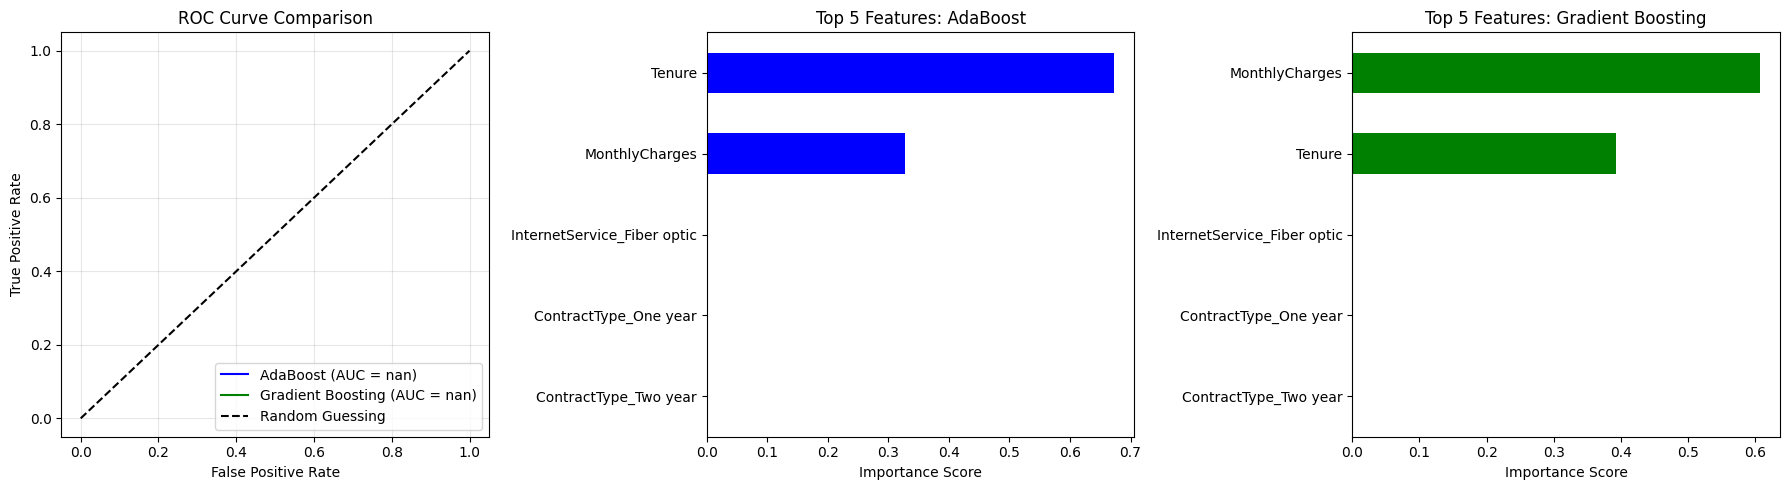

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
print("Rohith John 24BAD100")
# 1. Load the dataset
try:
    df = pd.read_csv('churn_boosting.csv')
except FileNotFoundError:
    print("Error: 'churn_boosting.csv' not found. Please check the file name and path.")
    exit()
# Convert 'Churn' (Yes/No) to binary (1/0) if it is in text format
if 'Churn' in df.columns and df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

# One-hot encode categorical features (like 'Contract Type')
# This converts categories into 1s and 0s in separate columns
df = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target variable (y)
# Drop missing values just in case
df = df.dropna()
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
ada_predictions = ada_model.predict(X_test)
ada_accuracy = accuracy_score(y_test, ada_predictions)

# 3. Train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_predictions)

# 4. Compare Performance
print(f"AdaBoost Accuracy: {ada_accuracy * 100:.2f}%")
print(f"Gradient Boosting Accuracy: {gb_accuracy * 100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualization 1: ROC Curve (Comparing both models)
# Get predicted probabilities for the positive class
ada_probs = ada_model.predict_proba(X_test)[:, 1]
gb_probs = gb_model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and Area Under Curve (AUC)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_probs)
auc_ada = auc(fpr_ada, tpr_ada)

fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)
auc_gb = auc(fpr_gb, tpr_gb)

axes[0].plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc_ada:.2f})', color='blue')
axes[0].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})', color='green')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guessing')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Visualization 2: Feature Importance (AdaBoost)
# Get top 5 features to keep the plot clean
ada_importance = pd.Series(ada_model.feature_importances_, index=X.columns).nlargest(5)
ada_importance.sort_values().plot(kind='barh', ax=axes[1], color='blue')
axes[1].set_title('Top 5 Features: AdaBoost')
axes[1].set_xlabel('Importance Score')

# Visualization 3: Feature Importance (Gradient Boosting)
gb_importance = pd.Series(gb_model.feature_importances_, index=X.columns).nlargest(5)
gb_importance.sort_values().plot(kind='barh', ax=axes[2], color='green')
axes[2].set_title('Top 5 Features: Gradient Boosting')
axes[2].set_xlabel('Importance Score')

# Adjust layout and display
plt.tight_layout()
plt.show()